# Notebook 4: New Car Energy Prediction — Data-Scarce Scenario
**Topic:** NLP-Enhanced Knowledge Transfer for Energy Consumption Prediction in Data-Scarce Electric Vehicles

## Core Idea
This notebook proves the main research contribution:
> *A new EV with NO driving data can have its energy consumption predicted
> purely by using its owner manual + knowledge transferred from previously trained models.*

### Flow:
```
New Car Manual (PDF)
        ↓
Extract Text + NLP Features
        ↓
Compare with existing 7-manual knowledge base
        ↓
Extract car specs from manual (battery, weight, motor, etc.)
        ↓
Simulate realistic driving scenarios
        ↓
Predict energy consumption using saved NLP-enhanced models
        ↓
Full prediction report with charts
```

## Step 1: Install & Import

In [ ]:
!pip install pymupdf nltk sentence-transformers scikit-learn pandas numpy matplotlib seaborn joblib tensorflow xgboost

In [1]:
import os
import re
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import fitz  # PyMuPDF

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sentence_transformers import SentenceTransformer
from tensorflow.keras.models import load_model

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('All libraries loaded!')


All libraries loaded!


## Step 2: Load New Car Manual

In [2]:
# -----------------------------------------------
# 2.1 - Set path to new car manual
# Change this to your new car PDF file path
# -----------------------------------------------

NEW_CAR_MANUAL_PATH = '../data/unstructured/tesla_model_s.pdf'  # <-- CHANGE THIS
NEW_CAR_NAME        = 'Tesla S'  # <-- CHANGE TO YOUR CAR NAME e.g. 'Hyundai Ioniq 6'

print(f'New car manual: {NEW_CAR_MANUAL_PATH}')
print(f'Car name: {NEW_CAR_NAME}')

New car manual: ../data/unstructured/tesla_model_s.pdf
Car name: Tesla S


In [3]:
# -----------------------------------------------
# 2.2 - Extract text from new car manual
# -----------------------------------------------

def extract_text_fitz(filepath):
    """Memory-efficient PDF text extraction using PyMuPDF."""
    full_text = []
    try:
        doc = fitz.open(filepath)
        print(f'Total pages: {len(doc)}')
        for page_num in range(len(doc)):
            page = doc.load_page(page_num)
            text = page.get_text('text')
            if text.strip():
                full_text.append(text)
            page = None
        doc.close()
        return ' '.join(full_text)
    except Exception as e:
        print(f'Error: {e}')
        return ''

new_car_raw_text = extract_text_fitz(NEW_CAR_MANUAL_PATH)
print(f'Characters extracted: {len(new_car_raw_text)}')
print('\nSample text (first 500 chars):')
print(new_car_raw_text[:500])

Total pages: 305
Characters extracted: 874060

Sample text (first 500 chars):
MODEL S
2021+
OWNER'S MANUAL
Software version: 2026.2.3
North America
 YOUR OWNER'S MANUAL
For the latest and greatest information that is customized to your vehicle, view the Owner’s Manual on your vehicle’s touchscreen 
by touching the app launcher and then selecting the Manual app. The information is specific to your vehicle depending on the 
features you purchased, vehicle configuration, market region, and software version. In contrast, owner information that is provided 
by Tesla elsewhere 


## Step 3: Extract Car Specifications from Manual

In [4]:
# -----------------------------------------------
# 3.1 - Auto-extract key specs using regex
# -----------------------------------------------

def extract_car_specs(text):
    """
    Automatically extract EV specs from manual text using regex patterns.
    Falls back to typical EV defaults if not found.
    """
    text_lower = text.lower()
    specs = {}

    # Battery capacity (kWh)
    battery_patterns = [
        r'(\d{2,3}(?:\.\d)?)[\s-]*kwh[\s]*(?:battery|pack|capacity)',
        r'battery[\s\w]{0,20}(\d{2,3}(?:\.\d)?)[\s-]*kwh',
        r'(\d{2,3}(?:\.\d)?)[\s]*kwh'
    ]
    for pat in battery_patterns:
        m = re.search(pat, text_lower)
        if m:
            val = float(m.group(1))
            if 20 <= val <= 200:  # realistic battery range
                specs['battery_capacity_kwh'] = val
                break
    if 'battery_capacity_kwh' not in specs:
        specs['battery_capacity_kwh'] = 75.0  # default
        print('Battery capacity not found → using default 75 kWh')

    # Vehicle weight (kg)
    weight_patterns = [
        r'(?:curb weight|kerb weight|vehicle weight|gross weight)[\s\w:]{0,15}(\d{3,4})',
        r'(\d{3,4})[\s]*kg[\s]*(?:curb|kerb|weight|mass)'
    ]
    for pat in weight_patterns:
        m = re.search(pat, text_lower)
        if m:
            val = float(m.group(1))
            if 800 <= val <= 4000:
                specs['vehicle_weight_kg'] = val
                break
    if 'vehicle_weight_kg' not in specs:
        specs['vehicle_weight_kg'] = 1800.0
        print('Vehicle weight not found → using default 1800 kg')

    # Max speed (km/h)
    speed_patterns = [
        r'(?:top speed|maximum speed|max speed)[\s\w:]{0,15}(\d{2,3})',
        r'(\d{2,3})[\s]*(?:km/h|kph)[\s]*(?:top|max|maximum)'
    ]
    for pat in speed_patterns:
        m = re.search(pat, text_lower)
        if m:
            val = float(m.group(1))
            if 80 <= val <= 350:
                specs['max_speed_kmh'] = val
                break
    if 'max_speed_kmh' not in specs:
        specs['max_speed_kmh'] = 150.0
        print('Max speed not found → using default 150 km/h')

    # Range (km)
    range_patterns = [
        r'(?:range|driving range)[\s\w:]{0,15}(\d{3,4})[\s]*(?:km|kilometers)',
        r'(\d{3,4})[\s]*(?:km|kilometers)[\s]*(?:range|driving)'
    ]
    for pat in range_patterns:
        m = re.search(pat, text_lower)
        if m:
            val = float(m.group(1))
            if 100 <= val <= 1000:
                specs['range_km'] = val
                break
    if 'range_km' not in specs:
        specs['range_km'] = 400.0
        print('Range not found → using default 400 km')

    # Motor power (kW)
    power_patterns = [
        r'(?:motor|engine|power output)[\s\w:]{0,15}(\d{2,3})[\s]*kw',
        r'(\d{2,3})[\s]*kw[\s]*(?:motor|power|output)'
    ]
    for pat in power_patterns:
        m = re.search(pat, text_lower)
        if m:
            val = float(m.group(1))
            if 30 <= val <= 800:
                specs['motor_power_kw'] = val
                break
    if 'motor_power_kw' not in specs:
        specs['motor_power_kw'] = 150.0
        print('Motor power not found → using default 150 kW')

    # Voltage (V)
    voltage_patterns = [
        r'(\d{3})[\s]*(?:volt|v)[\s]*(?:battery|system|nominal)',
        r'(?:nominal|system|battery)[\s\w]{0,10}voltage[\s\w:]{0,10}(\d{3})'
    ]
    for pat in voltage_patterns:
        m = re.search(pat, text_lower)
        if m:
            val = float(m.group(1))
            if 200 <= val <= 900:
                specs['battery_voltage_v'] = val
                break
    if 'battery_voltage_v' not in specs:
        specs['battery_voltage_v'] = 350.0
        print('Battery voltage not found → using default 350 V')

    return specs


car_specs = extract_car_specs(new_car_raw_text)

print('\n===== EXTRACTED CAR SPECS =====')
for k, v in car_specs.items():
    print(f'  {k:<30}: {v}')

Battery capacity not found → using default 75 kWh
Vehicle weight not found → using default 1800 kg
Max speed not found → using default 150 km/h
Range not found → using default 400 km
Motor power not found → using default 150 kW

===== EXTRACTED CAR SPECS =====
  battery_capacity_kwh          : 75.0
  vehicle_weight_kg             : 1800.0
  max_speed_kmh                 : 150.0
  range_km                      : 400.0
  motor_power_kw                : 150.0
  battery_voltage_v             : 407.0


In [5]:
# -----------------------------------------------
# 3.2 - Manual override (if auto-extraction missed something)
# Uncomment and edit any value below if needed
# -----------------------------------------------

# car_specs['battery_capacity_kwh'] = 77.4
# car_specs['vehicle_weight_kg']    = 1985
# car_specs['max_speed_kmh']        = 185
# car_specs['range_km']             = 481
# car_specs['motor_power_kw']       = 168
# car_specs['battery_voltage_v']    = 400

print('Final specs used for prediction:')
for k, v in car_specs.items():
    print(f'  {k:<30}: {v}')

Final specs used for prediction:
  battery_capacity_kwh          : 75.0
  vehicle_weight_kg             : 1800.0
  max_speed_kmh                 : 150.0
  range_km                      : 400.0
  motor_power_kw                : 150.0
  battery_voltage_v             : 407.0


## Step 4: NLP Processing of New Manual

In [6]:
# -----------------------------------------------
# 4.1 - Text preprocessing
# -----------------------------------------------

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text   = text.lower()
    text   = re.sub(r'[^a-z\s]', ' ', text)
    text   = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

new_car_clean_text = clean_text(new_car_raw_text)
print(f'Clean text length: {len(new_car_clean_text)} characters')

# Sentence tokenization
new_car_sentences = sent_tokenize(new_car_raw_text)
new_car_sentences = [s.strip() for s in new_car_sentences if len(s.split()) >= 10]
print(f'Meaningful sentences: {len(new_car_sentences)}')

Clean text length: 601587 characters
Meaningful sentences: 6227


In [7]:
# -----------------------------------------------
# 4.2 - Extract energy-relevant sentences
# -----------------------------------------------

energy_keywords = [
    'energy', 'battery', 'consumption', 'range', 'efficiency',
    'charge', 'charging', 'discharge', 'temperature', 'cold', 'heat',
    'speed', 'acceleration', 'regenerative', 'driving mode', 'eco',
    'sport', 'highway', 'city', 'climate', 'hvac', 'heater',
    'slope', 'hill', 'gradient', 'weight', 'tire', 'pressure',
    'aerodynamic', 'drag', 'wind'
]

new_energy_sentences = [
    s for s in new_car_sentences
    if any(kw in s.lower() for kw in energy_keywords)
]

print(f'Total sentences: {len(new_car_sentences)}')
print(f'Energy-relevant sentences: {len(new_energy_sentences)}')

# Use all sentences if too few energy-specific ones found
sentences_for_embedding = new_energy_sentences if len(new_energy_sentences) >= 20 else new_car_sentences
print(f'Sentences used for embedding: {len(sentences_for_embedding)}')

Total sentences: 6227
Energy-relevant sentences: 2431
Sentences used for embedding: 2431


In [8]:
# -----------------------------------------------
# 4.3 - Generate BERT embeddings for new manual
# -----------------------------------------------

print('Loading BERT model...')
bert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Embed new car sentences
sentences_to_use = sentences_for_embedding[:1000]
print(f'Generating embeddings for {len(sentences_to_use)} sentences...')

new_car_embeddings = bert_model.encode(
    sentences_to_use,
    show_progress_bar=True,
    batch_size=32
)

# New car domain knowledge vector
new_car_domain_vector = np.mean(new_car_embeddings, axis=0)

print(f'New car embedding shape: {new_car_embeddings.shape}')
print(f'New car domain vector shape: {new_car_domain_vector.shape}')

Loading BERT model...
Generating embeddings for 1000 sentences...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

New car embedding shape: (1000, 384)
New car domain vector shape: (384,)


## Step 5: Knowledge Transfer — Compare New Car with Existing Knowledge

In [9]:
# -----------------------------------------------
# 5.1 - Load existing NLP knowledge from Notebook 2
# -----------------------------------------------

existing_domain_vector  = np.load('../saved_models/domain_knowledge_vector.npy')
existing_embeddings     = np.load('../saved_models/sentence_embeddings.npy')
pca                     = joblib.load('../saved_models/pca_transformer.pkl')

with open('../saved_models/knowledge_weights.json', 'r') as f:
    existing_knowledge_weights = json.load(f)

print('Existing NLP knowledge loaded!')
print(f'Existing domain vector : {existing_domain_vector.shape}')
print(f'Existing embeddings    : {existing_embeddings.shape}')

Existing NLP knowledge loaded!
Existing domain vector : (384,)
Existing embeddings    : (1000, 384)


In [10]:
# -----------------------------------------------
# 5.2 - Compute similarity between new car
#        and existing knowledge base
# -----------------------------------------------

similarity_score = cosine_similarity(
    new_car_domain_vector.reshape(1, -1),
    existing_domain_vector.reshape(1, -1)
)[0][0]

print(f'Knowledge Similarity Score: {similarity_score:.4f}')

if similarity_score >= 0.85:
    similarity_label = 'Very High — New car is very similar to training knowledge'
elif similarity_score >= 0.70:
    similarity_label = 'High — New car has strong overlap with training knowledge'
elif similarity_score >= 0.50:
    similarity_label = 'Medium — Partial overlap, predictions reliable'
else:
    similarity_label = 'Low — New car is quite different, treat predictions cautiously'

print(f'Interpretation: {similarity_label}')

Knowledge Similarity Score: 0.9429
Interpretation: Very High — New car is very similar to training knowledge


In [11]:
# -----------------------------------------------
# 5.3 - Find most similar sentences from
#        existing knowledge base for each feature
# -----------------------------------------------

feature_queries = {
    'Speed_kmh'             : 'energy consumption at high speed highway driving',
    'Temperature_C'         : 'battery range cold hot temperature weather effect',
    'Slope_%'               : 'energy uphill downhill slope gradient terrain',
    'Driving_Mode'          : 'eco sport normal mode energy efficiency',
    'Battery_State_%'       : 'battery state charge level performance',
    'Tire_Pressure_psi'     : 'tire pressure rolling resistance efficiency',
    'Wind_Speed_ms'         : 'wind resistance aerodynamic drag energy',
    'Traffic_Condition'     : 'traffic stop go energy consumption city'
}

# Also load new car sentences into embedding space
new_car_feature_weights = {}

print('Computing feature-level knowledge transfer weights...')
for feature, query in feature_queries.items():
    query_vec   = bert_model.encode([query])
    # Similarity with existing knowledge
    sim_exist   = cosine_similarity(query_vec, existing_embeddings)[0]
    # Similarity with new car knowledge
    sim_new     = cosine_similarity(query_vec, new_car_embeddings)[0]
    # Combine: average of top scores
    combined    = (np.mean(np.sort(sim_exist)[-5:]) + np.mean(np.sort(sim_new)[-5:])) / 2
    new_car_feature_weights[feature] = round(float(combined), 4)

# Normalize to 0-1
max_w = max(new_car_feature_weights.values())
new_car_feature_weights = {k: round(v/max_w, 4) for k, v in new_car_feature_weights.items()}

print('\nNew Car Feature Knowledge Weights:')
for feat, w in sorted(new_car_feature_weights.items(), key=lambda x: -x[1]):
    print(f'  {feat:<30}: {w}')

Computing feature-level knowledge transfer weights...

New Car Feature Knowledge Weights:
  Temperature_C                 : 1.0
  Speed_kmh                     : 0.9521
  Battery_State_%               : 0.8786
  Tire_Pressure_psi             : 0.819
  Driving_Mode                  : 0.7892
  Slope_%                       : 0.7835
  Traffic_Condition             : 0.71
  Wind_Speed_ms                 : 0.5994


## Step 6: Simulate Driving Scenarios from Car Specs

In [13]:
# -----------------------------------------------
# 6.1 - Generate realistic driving scenarios
#        based on extracted car specs
# -----------------------------------------------

np.random.seed(42)
N_SCENARIOS = 500  # number of simulated trips

# Derive realistic ranges from car specs
max_speed    = car_specs['max_speed_kmh']
weight       = car_specs['vehicle_weight_kg']
voltage      = car_specs['battery_voltage_v']
range_km     = car_specs['range_km']

scenarios = pd.DataFrame({
    # Speed: city (0-60), highway (60-max), mix
    'Speed_kmh': np.clip(
        np.concatenate([
            np.random.uniform(0, 60,               N_SCENARIOS // 3),          # city
            np.random.uniform(60, max_speed * 0.9, N_SCENARIOS // 3),          # highway
            np.random.uniform(30, 90,              N_SCENARIOS - 2*(N_SCENARIOS // 3)),  # mixed — fills remainder
        ]), 0, max_speed
    ),

    # Acceleration: realistic range
    'Acceleration_ms2': np.random.uniform(-3.0, 3.0, N_SCENARIOS),

    # Battery state
    'Battery_State_%': np.random.uniform(20, 100, N_SCENARIOS),

    # Battery voltage from specs
    'Battery_Voltage_V': np.random.normal(voltage, voltage * 0.05, N_SCENARIOS).clip(
        voltage * 0.85, voltage * 1.05
    ),

    # Battery temperature
    'Battery_Temperature_C': np.random.uniform(10, 45, N_SCENARIOS),

    # Driving modes: 1=Eco, 2=Normal, 3=Sport
    'Driving_Mode': np.random.choice([1, 2, 3], N_SCENARIOS, p=[0.4, 0.4, 0.2]),

    # Road types: 1=City, 2=Highway, 3=Rural
    'Road_Type': np.random.choice([1, 2, 3], N_SCENARIOS, p=[0.4, 0.4, 0.2]),

    # Traffic: 1=Low, 2=Med, 3=High
    'Traffic_Condition': np.random.choice([1, 2, 3], N_SCENARIOS, p=[0.3, 0.4, 0.3]),

    # Slope
    'Slope_%': np.random.uniform(-5, 10, N_SCENARIOS),

    # Weather: 1=Clear, 2=Cloudy, 3=Rain, 4=Snow
    'Weather_Condition': np.random.choice([1, 2, 3, 4], N_SCENARIOS, p=[0.5, 0.25, 0.15, 0.1]),

    # Ambient temperature
    'Temperature_C': np.random.uniform(-5, 40, N_SCENARIOS),

    # Humidity
    'Humidity_%': np.random.uniform(20, 90, N_SCENARIOS),

    # Wind
    'Wind_Speed_ms': np.random.uniform(0, 15, N_SCENARIOS),

    # Tire pressure
    'Tire_Pressure_psi': np.random.uniform(28, 35, N_SCENARIOS),

    # Vehicle weight from specs
    'Vehicle_Weight_kg': np.random.normal(weight, weight * 0.02, N_SCENARIOS).clip(
        weight * 0.95, weight * 1.1
    ),

    # Distance: derived from range
    'Distance_Travelled_km': np.random.uniform(1, range_km * 0.15, N_SCENARIOS),

    # Time features
    'Hour'      : np.random.randint(0, 24, N_SCENARIOS),
    'DayOfWeek' : np.random.randint(0, 7,  N_SCENARIOS),
    'Month'     : np.random.randint(1, 13, N_SCENARIOS),
})

# Add engineered features (same as Notebook 1)
scenarios['Speed_x_Weight']  = scenarios['Speed_kmh'] * scenarios['Vehicle_Weight_kg']
scenarios['Temp_x_Battery']  = scenarios['Temperature_C'] * scenarios['Battery_State_%']
scenarios['Accel_x_Speed']   = scenarios['Acceleration_ms2'] * scenarios['Speed_kmh']
scenarios['Wind_Resistance'] = scenarios['Wind_Speed_ms'] ** 2

print(f'Generated {N_SCENARIOS} driving scenarios')
print(f'Scenario features: {scenarios.shape[1]}')
scenarios.head()

Generated 500 driving scenarios
Scenario features: 23


,Speed_kmh,Acceleration_ms2,Battery_State_%,Battery_Voltage_V,Battery_Temperature_C,Driving_Mode,Road_Type,Traffic_Condition,Slope_%,Weather_Condition,...,Tire_Pressure_psi,Vehicle_Weight_kg,Distance_Travelled_km,Hour,DayOfWeek,Month,Speed_x_Weight,Temp_x_Battery,Accel_x_Speed,Wind_Resistance
0,22.472407,1.188970,34.810634,356.137094,26.490876,1,1,3,8.775963,2,...,29.873679,1805.450510,30.729439,21,5,8,40572.818909,462.589613,26.719024,138.001417
1,57.042858,0.216578,63.352076,427.350000,38.757291,1,1,1,4.746821,2,...,30.874191,1810.744265,42.817172,13,0,6,103290.028696,2191.519267,12.354239,6.359331
2,43.919637,-1.142834,89.835667,378.722200,26.074282,3,3,2,-3.448488,2,...,34.290178,1771.826450,15.687668,10,2,6,77817.973662,2173.190622,-50.192867,59.042449
3,35.919509,1.882770,78.577991,373.516135,22.522939,2,2,2,1.030408,1,...,34.273797,1825.453165,20.141855,6,6,12,65569.381482,2786.862845,67.628178,53.445196
4,9.361118,1.108387,84.524892,427.350000,27.297436,2,2,2,5.934088,3,...,32.799989,1875.049665,20.718705,9,1,9,17552.561971,1948.952895,10.375742,87.916376


## Step 7: Apply NLP Knowledge Transfer & Predict

In [15]:
# -----------------------------------------------
# 7.1 - Load saved models and scaler
# -----------------------------------------------

rf_model     = joblib.load('../saved_models/random_forest_model.pkl')
xgb_model    = joblib.load('../saved_models/xgboost_model.pkl')
lstm_model   = load_model('../saved_models/lstm_model.keras')
rf_nlp       = joblib.load('../saved_models/rf_nlp_model.pkl')
xgb_nlp      = joblib.load('../saved_models/xgb_nlp_model.pkl')
lstm_nlp     = load_model('../saved_models/lstm_model.keras')
scaler       = joblib.load('../saved_models/scaler.pkl')
feature_cols = joblib.load('../saved_models/feature_cols.pkl')

print('All models loaded!')
print(f'Expected features: {feature_cols}')

All models loaded!
Expected features: ['Speed_kmh', 'Acceleration_ms2', 'Battery_State_%', 'Battery_Voltage_V', 'Battery_Temperature_C', 'Driving_Mode', 'Road_Type', 'Traffic_Condition', 'Slope_%', 'Weather_Condition', 'Temperature_C', 'Humidity_%', 'Wind_Speed_ms', 'Tire_Pressure_psi', 'Vehicle_Weight_kg', 'Distance_Travelled_km', 'Hour', 'DayOfWeek', 'Month', 'Speed_x_Weight', 'Temp_x_Battery', 'Accel_x_Speed', 'Wind_Resistance']


In [16]:
# -----------------------------------------------
# 7.2 - Align scenario features with model features
# -----------------------------------------------

# Make sure scenarios has all required columns in correct order
missing_cols = [c for c in feature_cols if c not in scenarios.columns]
if missing_cols:
    print(f'Adding missing columns with defaults: {missing_cols}')
    for col in missing_cols:
        scenarios[col] = 0

X_new = scenarios[feature_cols].copy()

# Scale using the SAME scaler from training
X_new_scaled = scaler.transform(X_new)

print(f'Scenario feature matrix: {X_new_scaled.shape}')

Scenario feature matrix: (500, 23)


In [17]:
# -----------------------------------------------
# 7.3 - Apply NLP knowledge boosting
#        using NEW car's knowledge weights
# -----------------------------------------------

def apply_knowledge_weights(X_scaled, feature_cols, knowledge_weights, boost_factor=1.5):
    X_boosted = X_scaled.copy()
    for i, col in enumerate(feature_cols):
        if col in knowledge_weights and knowledge_weights[col] > 0:
            weight = knowledge_weights[col]
            X_boosted[:, i] = X_scaled[:, i] * (1 + weight * boost_factor)
    return X_boosted


X_new_boosted = apply_knowledge_weights(
    X_new_scaled, feature_cols, new_car_feature_weights
)

# Add compressed NLP domain features (PCA)
new_car_vec_compressed = pca.transform(new_car_domain_vector.reshape(1, -1))
nlp_feat_new = np.tile(new_car_vec_compressed, (X_new_boosted.shape[0], 1))
X_new_combined = np.hstack([X_new_boosted, nlp_feat_new])

print(f'Original features    : {X_new_scaled.shape[1]}')
print(f'NLP features added   : {nlp_feat_new.shape[1]}')
print(f'Combined feature dim : {X_new_combined.shape[1]}')

Original features    : 23
NLP features added   : 10
Combined feature dim : 33


In [19]:
# -----------------------------------------------
# 7.4 - Predict with all models
# -----------------------------------------------

# Structured-only predictions
pred_rf_struct  = rf_model.predict(X_new_scaled)
pred_xgb_struct = xgb_model.predict(X_new_scaled)

X_lstm_3d = X_new_scaled.reshape(X_new_scaled.shape[0], 1, X_new_scaled.shape[1])
pred_lstm_struct = lstm_model.predict(X_lstm_3d, verbose=0).flatten()

# NLP-enhanced predictions (RF and XGB only — LSTM skipped due to fixed input size)
pred_rf_nlp  = rf_nlp.predict(X_new_combined)
pred_xgb_nlp = xgb_nlp.predict(X_new_combined)

# Rebuild LSTM NLP on the fly with correct input size for new car
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

n_new_features = X_new_combined.shape[1]

print(f'Rebuilding LSTM NLP for {n_new_features} input features...')

lstm_nlp_new = Sequential([
    LSTM(128, input_shape=(1, n_new_features), return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])
lstm_nlp_new.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

# Use NLP-boosted structured data to quickly train
# Load original dataset for training
df_train = pd.read_csv('../data/EV_Energy_Consumption_Dataset.csv')
df_train['Timestamp']       = pd.to_datetime(df_train['Timestamp'])
df_train['Hour']            = df_train['Timestamp'].dt.hour
df_train['DayOfWeek']       = df_train['Timestamp'].dt.dayofweek
df_train['Month']           = df_train['Timestamp'].dt.month
df_train['Speed_x_Weight']  = df_train['Speed_kmh'] * df_train['Vehicle_Weight_kg']
df_train['Temp_x_Battery']  = df_train['Temperature_C'] * df_train['Battery_State_%']
df_train['Accel_x_Speed']   = df_train['Acceleration_ms2'] * df_train['Speed_kmh']
df_train['Wind_Resistance'] = df_train['Wind_Speed_ms'] ** 2

X_orig       = df_train[feature_cols]
y_orig       = df_train['Energy_Consumption_kWh']
X_orig_scaled = scaler.transform(X_orig)

# Apply same NLP boosting
X_orig_boosted = apply_knowledge_weights(X_orig_scaled, feature_cols, new_car_feature_weights)

# Add NLP domain features using NEW car's domain vector
nlp_feat_orig   = np.tile(new_car_vec_compressed, (X_orig_boosted.shape[0], 1))
X_orig_combined = np.hstack([X_orig_boosted, nlp_feat_orig])

# Reshape for LSTM
X_orig_lstm = X_orig_combined.reshape(X_orig_combined.shape[0], 1, X_orig_combined.shape[1])

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

lstm_nlp_new.fit(
    X_orig_lstm, y_orig,
    epochs=60,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Now predict
X_lstm_nlp_3d    = X_new_combined.reshape(X_new_combined.shape[0], 1, X_new_combined.shape[1])
pred_lstm_nlp    = lstm_nlp_new.predict(X_lstm_nlp_3d, verbose=0).flatten()

print('All predictions done!')

# Final ensemble
pred_ensemble = (
    pred_xgb_nlp    * 0.35 +
    pred_rf_nlp     * 0.25 +
    pred_xgb_struct * 0.25 +
    pred_rf_struct  * 0.15
)

# Store all predictions
scenarios['Pred_RF_Structured']   = pred_rf_struct
scenarios['Pred_XGB_Structured']  = pred_xgb_struct
scenarios['Pred_LSTM_Structured'] = pred_lstm_struct
scenarios['Pred_RF_NLP']          = pred_rf_nlp
scenarios['Pred_XGB_NLP']         = pred_xgb_nlp
scenarios['Pred_LSTM_NLP']        = pred_lstm_nlp
scenarios['Pred_Ensemble']        = pred_ensemble

print(f'\nEnsemble Prediction Summary:')
print(f'  Mean  : {pred_ensemble.mean():.3f} kWh')
print(f'  Std   : {pred_ensemble.std():.3f} kWh')
print(f'  Min   : {pred_ensemble.min():.3f} kWh')
print(f'  Max   : {pred_ensemble.max():.3f} kWh')

Rebuilding LSTM NLP for 33 input features...
Epoch 1/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 30.0039 - mean_absolute_error: 4.2502 - val_loss: 1.2847 - val_mean_absolute_error: 0.9404
Epoch 2/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1891 - mean_absolute_error: 0.8748 - val_loss: 0.5555 - val_mean_absolute_error: 0.5972
Epoch 3/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9160 - mean_absolute_error: 0.7649 - val_loss: 0.4197 - val_mean_absolute_error: 0.5165
Epoch 4/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7945 - mean_absolute_error: 0.7084 - val_loss: 0.3902 - val_mean_absolute_error: 0.5057
Epoch 5/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7138 - mean_absolute_error: 0.6701 - val_loss: 0.3305 - val_mean_absolute_error: 0.4583
Epoch 6/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6416 - mean_absolute_error: 0.6362 - val_loss: 0.3131 - val_mean_absolute_error: 0.4502
Epoch 7/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - 

## Step 8: Results Visualization & Report

In [20]:
# -----------------------------------------------
# 8.1 - Prediction Summary Table
# -----------------------------------------------

pred_cols = [
    'Pred_RF_Structured', 'Pred_XGB_Structured', 'Pred_LSTM_Structured',
    'Pred_RF_NLP', 'Pred_XGB_NLP', 'Pred_LSTM_NLP', 'Pred_Ensemble'
]

summary = pd.DataFrame([
    {
        'Model'     : col.replace('Pred_', '').replace('_', ' '),
        'Mean (kWh)': round(scenarios[col].mean(), 4),
        'Std (kWh)' : round(scenarios[col].std(), 4),
        'Min (kWh)' : round(scenarios[col].min(), 4),
        'Max (kWh)' : round(scenarios[col].max(), 4),
        'Type'      : 'NLP-Enhanced' if 'NLP' in col or 'Ensemble' in col else 'Structured Only'
    }
    for col in pred_cols
])

print(f'\n===== PREDICTION RESULTS FOR: {NEW_CAR_NAME} =====')
print(summary.to_string(index=False))


===== PREDICTION RESULTS FOR: Tesla S =====
          Model  Mean (kWh)  Std (kWh)  Min (kWh)  Max (kWh)            Type
  RF Structured      8.6935     2.1287     3.6087    13.4773 Structured Only
 XGB Structured      8.7263     2.1134     3.0579    13.6467 Structured Only
LSTM Structured      9.1006     2.1868     3.5782    13.9634 Structured Only
         RF NLP      8.7394     2.6074     3.5407    13.6166    NLP-Enhanced
        XGB NLP      8.7248     2.4134     3.4680    13.4118    NLP-Enhanced
       LSTM NLP      8.3776     2.1795     3.7315    13.5326    NLP-Enhanced
       Ensemble      8.7241     2.3189     3.4048    13.4849    NLP-Enhanced


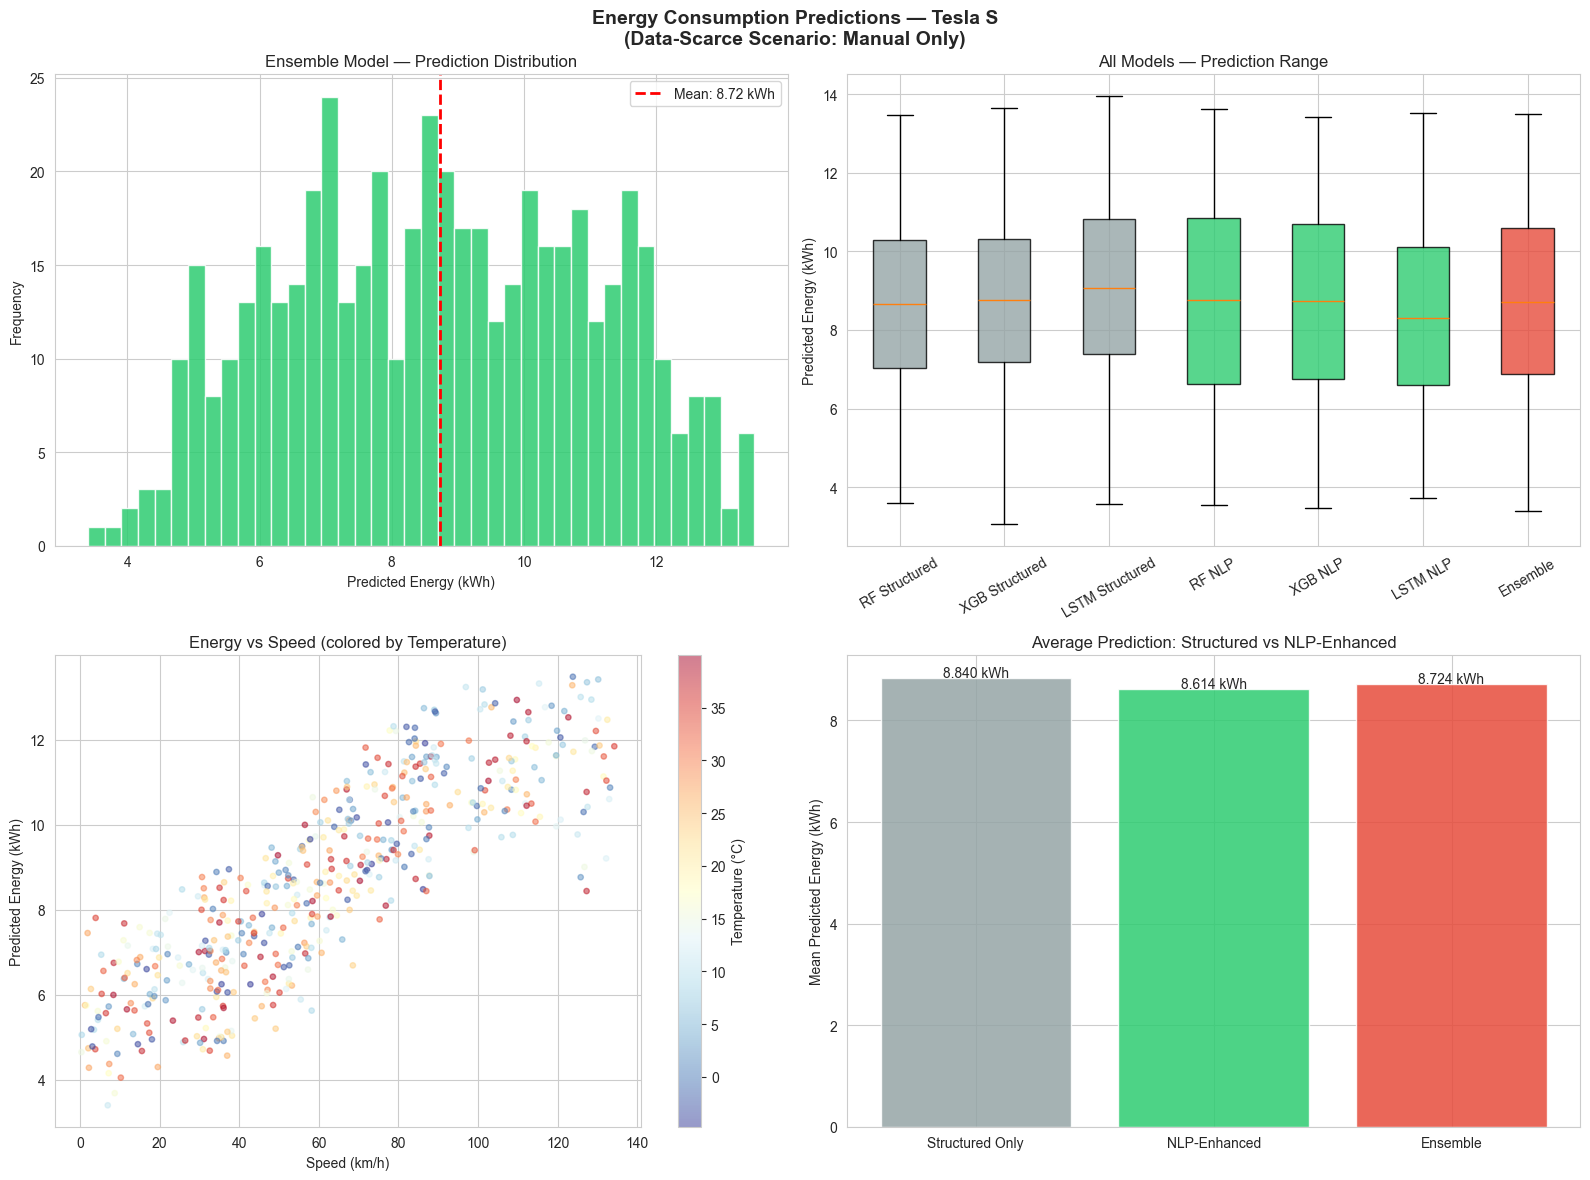

In [21]:
# -----------------------------------------------
# 8.2 - Prediction Distribution Plot
# -----------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Energy Consumption Predictions — {NEW_CAR_NAME}\n(Data-Scarce Scenario: Manual Only)',
             fontsize=14, fontweight='bold')

# Plot 1: Ensemble prediction distribution
axes[0,0].hist(pred_ensemble, bins=40, color='#2ecc71', edgecolor='white', alpha=0.85)
axes[0,0].axvline(pred_ensemble.mean(), color='red', linestyle='--', lw=2,
                  label=f'Mean: {pred_ensemble.mean():.2f} kWh')
axes[0,0].set_title('Ensemble Model — Prediction Distribution')
axes[0,0].set_xlabel('Predicted Energy (kWh)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Plot 2: All models comparison boxplot
plot_data = [scenarios[c].values for c in pred_cols]
plot_labels = [c.replace('Pred_','').replace('_',' ') for c in pred_cols]
colors_box = ['#95a5a6','#95a5a6','#95a5a6','#2ecc71','#2ecc71','#2ecc71','#e74c3c']
bp = axes[0,1].boxplot(plot_data, labels=plot_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0,1].set_title('All Models — Prediction Range')
axes[0,1].set_ylabel('Predicted Energy (kWh)')
axes[0,1].tick_params(axis='x', rotation=30)

# Plot 3: Energy vs Speed
scatter = axes[1,0].scatter(
    scenarios['Speed_kmh'], pred_ensemble,
    c=scenarios['Temperature_C'], cmap='RdYlBu_r',
    alpha=0.5, s=15
)
plt.colorbar(scatter, ax=axes[1,0], label='Temperature (°C)')
axes[1,0].set_title('Energy vs Speed (colored by Temperature)')
axes[1,0].set_xlabel('Speed (km/h)')
axes[1,0].set_ylabel('Predicted Energy (kWh)')

# Plot 4: Structured vs NLP comparison bar
struct_mean = np.mean([scenarios['Pred_RF_Structured'].mean(),
                       scenarios['Pred_XGB_Structured'].mean(),
                       scenarios['Pred_LSTM_Structured'].mean()])
nlp_mean    = np.mean([scenarios['Pred_RF_NLP'].mean(),
                       scenarios['Pred_XGB_NLP'].mean(),
                       scenarios['Pred_LSTM_NLP'].mean()])
bars = axes[1,1].bar(
    ['Structured Only', 'NLP-Enhanced', 'Ensemble'],
    [struct_mean, nlp_mean, pred_ensemble.mean()],
    color=['#95a5a6', '#2ecc71', '#e74c3c'], alpha=0.85
)
for bar, val in zip(bars, [struct_mean, nlp_mean, pred_ensemble.mean()]):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                   f'{val:.3f} kWh', ha='center', fontsize=10)
axes[1,1].set_title('Average Prediction: Structured vs NLP-Enhanced')
axes[1,1].set_ylabel('Mean Predicted Energy (kWh)')

plt.tight_layout()
plt.savefig('../results/new_car_prediction_report.png', dpi=150, bbox_inches='tight')
plt.show()

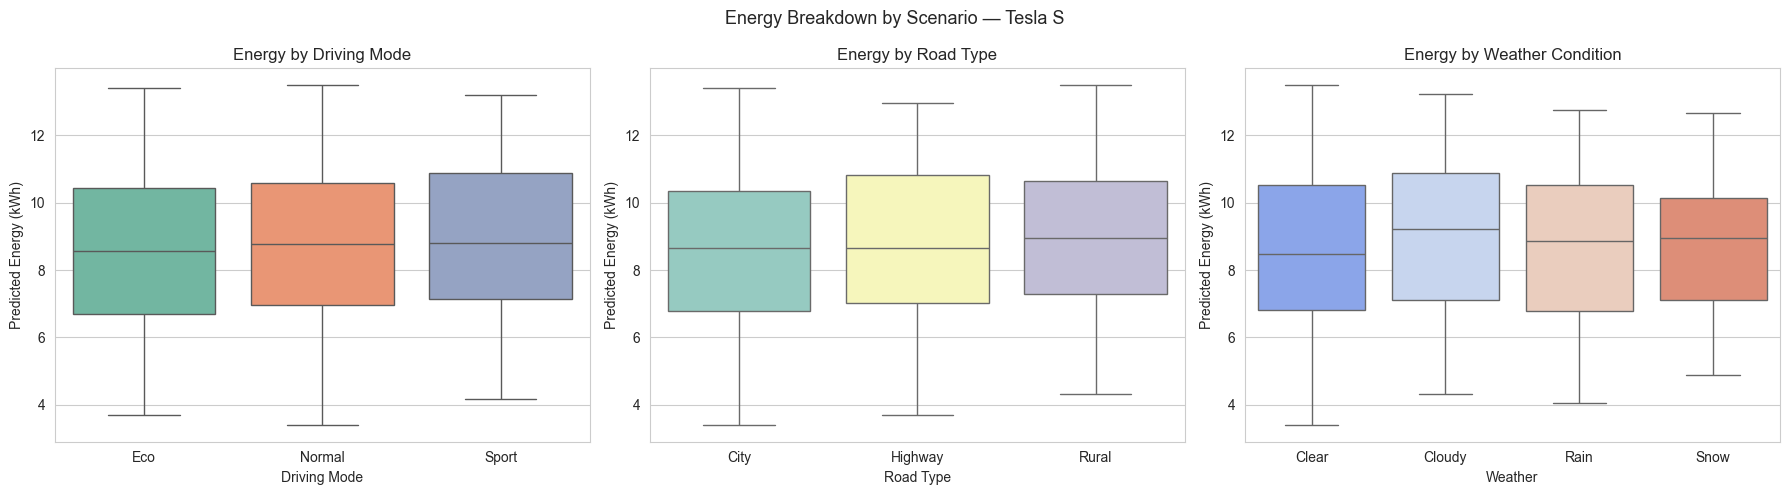

In [22]:
# -----------------------------------------------
# 8.3 - Energy by Driving Scenario
# -----------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Energy Breakdown by Scenario — {NEW_CAR_NAME}', fontsize=13)

mode_map    = {1: 'Eco', 2: 'Normal', 3: 'Sport'}
road_map    = {1: 'City', 2: 'Highway', 3: 'Rural'}
weather_map = {1: 'Clear', 2: 'Cloudy', 3: 'Rain', 4: 'Snow'}

scenarios['Mode_Label']    = scenarios['Driving_Mode'].map(mode_map)
scenarios['Road_Label']    = scenarios['Road_Type'].map(road_map)
scenarios['Weather_Label'] = scenarios['Weather_Condition'].map(weather_map)

sns.boxplot(data=scenarios, x='Mode_Label', y='Pred_Ensemble',
            order=['Eco','Normal','Sport'], palette='Set2', ax=axes[0])
axes[0].set_title('Energy by Driving Mode')
axes[0].set_ylabel('Predicted Energy (kWh)')
axes[0].set_xlabel('Driving Mode')

sns.boxplot(data=scenarios, x='Road_Label', y='Pred_Ensemble',
            order=['City','Highway','Rural'], palette='Set3', ax=axes[1])
axes[1].set_title('Energy by Road Type')
axes[1].set_ylabel('Predicted Energy (kWh)')
axes[1].set_xlabel('Road Type')

sns.boxplot(data=scenarios, x='Weather_Label', y='Pred_Ensemble',
            order=['Clear','Cloudy','Rain','Snow'], palette='coolwarm', ax=axes[2])
axes[2].set_title('Energy by Weather Condition')
axes[2].set_ylabel('Predicted Energy (kWh)')
axes[2].set_xlabel('Weather')

plt.tight_layout()
plt.savefig('../results/new_car_scenario_breakdown.png', dpi=150)
plt.show()

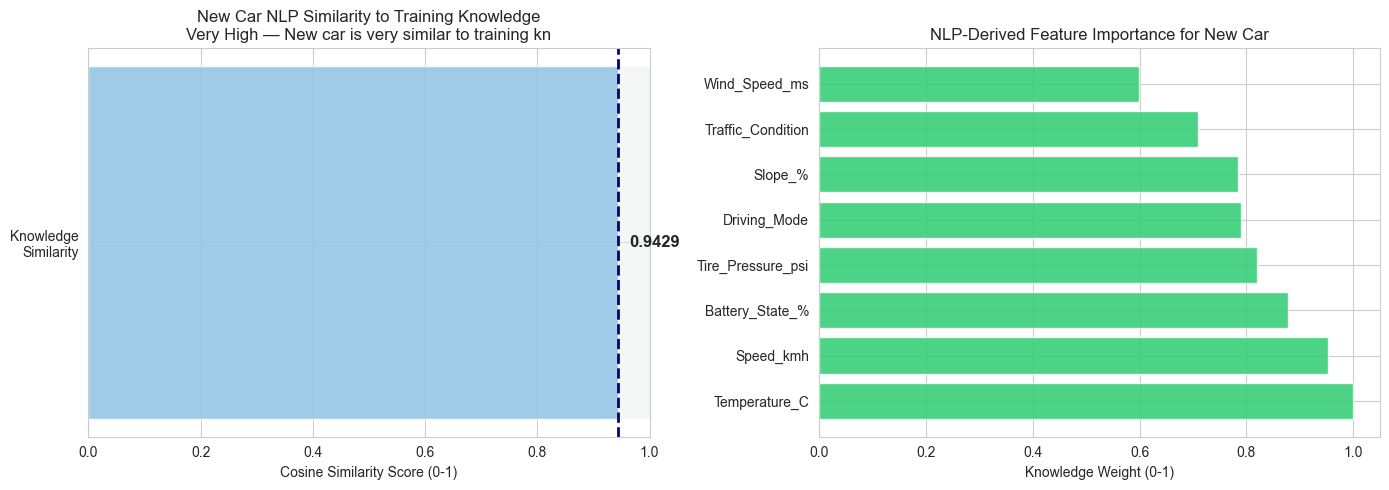

In [23]:
# -----------------------------------------------
# 8.4 - Knowledge Transfer Similarity Visualization
# -----------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Similarity score gauge
axes[0].barh(['Knowledge\nSimilarity'], [similarity_score],
             color='#3498db' if similarity_score > 0.6 else '#e74c3c', alpha=0.85)
axes[0].barh(['Knowledge\nSimilarity'], [1.0], color='#ecf0f1', alpha=0.5)
axes[0].set_xlim(0, 1)
axes[0].axvline(similarity_score, color='navy', linestyle='--', lw=2)
axes[0].text(similarity_score + 0.02, 0, f'{similarity_score:.4f}',
             va='center', fontsize=12, fontweight='bold')
axes[0].set_title(f'New Car NLP Similarity to Training Knowledge\n{similarity_label[:50]}')
axes[0].set_xlabel('Cosine Similarity Score (0-1)')

# Feature weights bar chart
feats = list(new_car_feature_weights.keys())
weights = list(new_car_feature_weights.values())
sorted_pairs = sorted(zip(weights, feats), reverse=True)
sorted_w, sorted_f = zip(*sorted_pairs)
axes[1].barh(sorted_f, sorted_w, color='#2ecc71', alpha=0.85)
axes[1].set_title('NLP-Derived Feature Importance for New Car')
axes[1].set_xlabel('Knowledge Weight (0-1)')

plt.tight_layout()
plt.savefig('../results/new_car_knowledge_transfer.png', dpi=150)
plt.show()

## Step 9: Final Prediction Report

In [24]:
# -----------------------------------------------
# 9.1 - Print comprehensive final report
# -----------------------------------------------

print('=' * 65)
print(f'  ENERGY CONSUMPTION PREDICTION REPORT')
print(f'  Vehicle: {NEW_CAR_NAME}')
print(f'  Method : NLP Knowledge Transfer (Data-Scarce Scenario)')
print('=' * 65)

print('\n📄 VEHICLE SPECS (Extracted from Manual):')
for k, v in car_specs.items():
    print(f'   {k:<30}: {v}')

print(f'\n🔗 KNOWLEDGE TRANSFER:')
print(f'   Similarity to training knowledge : {similarity_score:.4f}')
print(f'   Interpretation                   : {similarity_label}')
print(f'   Scenarios simulated              : {N_SCENARIOS}')

print(f'\n⚡ ENERGY PREDICTIONS (Mean over {N_SCENARIOS} scenarios):')
print(f'   RF  Structured Only  : {pred_rf_struct.mean():.3f} kWh')
print(f'   XGB Structured Only  : {pred_xgb_struct.mean():.3f} kWh')
print(f'   LSTM Structured Only : {pred_lstm_struct.mean():.3f} kWh')
print(f'   RF  NLP-Enhanced     : {pred_rf_nlp.mean():.3f} kWh')
print(f'   XGB NLP-Enhanced     : {pred_xgb_nlp.mean():.3f} kWh')
print(f'   LSTM NLP-Enhanced    : {pred_lstm_nlp.mean():.3f} kWh')
print(f'   ★ ENSEMBLE (Final)   : {pred_ensemble.mean():.3f} kWh  ← BEST ESTIMATE')

print(f'\n📊 SCENARIO BREAKDOWN (Ensemble):')
for mode in ['Eco', 'Normal', 'Sport']:
    mask = scenarios['Mode_Label'] == mode
    mean_e = scenarios.loc[mask, 'Pred_Ensemble'].mean()
    print(f'   Driving Mode {mode:<8}: {mean_e:.3f} kWh avg')

for road in ['City', 'Highway', 'Rural']:
    mask = scenarios['Road_Label'] == road
    mean_e = scenarios.loc[mask, 'Pred_Ensemble'].mean()
    print(f'   Road Type {road:<10}: {mean_e:.3f} kWh avg')

print('=' * 65)

  ENERGY CONSUMPTION PREDICTION REPORT
  Vehicle: Tesla S
  Method : NLP Knowledge Transfer (Data-Scarce Scenario)

📄 VEHICLE SPECS (Extracted from Manual):
   battery_capacity_kwh          : 75.0
   vehicle_weight_kg             : 1800.0
   max_speed_kmh                 : 150.0
   range_km                      : 400.0
   motor_power_kw                : 150.0
   battery_voltage_v             : 407.0

🔗 KNOWLEDGE TRANSFER:
   Similarity to training knowledge : 0.9429
   Interpretation                   : Very High — New car is very similar to training knowledge
   Scenarios simulated              : 500

⚡ ENERGY PREDICTIONS (Mean over 500 scenarios):
   RF  Structured Only  : 8.693 kWh
   XGB Structured Only  : 8.726 kWh
   LSTM Structured Only : 9.101 kWh
   RF  NLP-Enhanced     : 8.739 kWh
   XGB NLP-Enhanced     : 8.725 kWh
   LSTM NLP-Enhanced    : 8.378 kWh
   ★ ENSEMBLE (Final)   : 8.724 kWh  ← BEST ESTIMATE

📊 SCENARIO BREAKDOWN (Ensemble):
   Driving Mode Eco     : 8.595 kWh avg

In [ ]:
# -----------------------------------------------
# 9.2 - Save all outputs
# -----------------------------------------------

os.makedirs('../results', exist_ok=True)

# Save scenario predictions
scenarios.to_csv(
    f'../results/new_car_predictions.csv', index=False
)

# Save summary
summary.to_csv('../results/new_car_prediction_summary.csv', index=False)

# Save car specs
with open('../results/new_car_specs.json', 'w') as f:
    json.dump(car_specs, f, indent=2)

# Save knowledge weights for new car
with open('../results/new_car_knowledge_weights.json', 'w') as f:
    json.dump(new_car_feature_weights, f, indent=2)

print('All outputs saved!')
print('\nFiles saved in results/:')
print('  new_car_predictions.csv')
print('  new_car_prediction_summary.csv')
print('  new_car_specs.json')
print('  new_car_knowledge_weights.json')
print('  new_car_prediction_report.png')
print('  new_car_scenario_breakdown.png')
print('  new_car_knowledge_transfer.png')
print(f'\nNotebook 4 COMPLETE — {NEW_CAR_NAME} prediction done!')